# buyers or sellers? who wins?
## dara prep and dependencies
data used is from https://www.kaggle.com/code/itoeiji/deep-reinforcement-learning-on-stock-data and contains daily stock data (values for open, close, high, low and openInt) for several public companies in the united states.

In [2]:
import numpy as np
import pandas as pd
import time
import copy

In [3]:
data = pd.read_csv('./data/aapl.us.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')
# for now, we shall operate on a small subset
data = data.iloc[:100]
print(data.index.min(), data.index.max())

1984-09-07 00:00:00 1985-01-29 00:00:00


In [4]:
data

,Open,High,Low,Close,Volume,OpenInt
Date,,,,,,
1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0
1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0
1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0
1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0
1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0
...,...,...,...,...,...,...
1985-01-23,0.48027,0.48291,0.47251,0.47251,120060735,0
1985-01-24,0.47251,0.47251,0.46357,0.46357,110733964,0
1985-01-25,0.46357,0.47251,0.45335,0.47251,88813324,0


## intuitive setup
we need to be able to make simple intuitive measurements on candle sick data. each candle stick is essentially a snapshot of a conversation between  buyers and sellers. when a candle closes higher than it opened, it means buyers won that round, and when it closes lower, sellers won. the size of the body tells you how decisively they won

so lets add another column to the dataframe labeled "winner" (bool)
    "buyers" if close > open
    "sellers" if close < open
    "neutral" if close == open

In [5]:
def determine_winners(row):
    if row['Close'] > row['Open']:
        return 'buyers'
    elif row['Close'] < row['Open']:
        return 'sellers'
    else:
        return 'neutral'

In [6]:
data['winner'] = data.apply(determine_winners, axis=1)

In [7]:
data

,Open,High,Low,Close,Volume,OpenInt,winner
Date,,,,,,,
1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0,neutral
1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0,sellers
1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0,buyers
1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0,sellers
1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0,neutral
...,...,...,...,...,...,...,...
1985-01-23,0.48027,0.48291,0.47251,0.47251,120060735,0,sellers
1985-01-24,0.47251,0.47251,0.46357,0.46357,110733964,0,sellers
1985-01-25,0.46357,0.47251,0.45335,0.47251,88813324,0,buyers


In [8]:
import matplotlib.pyplot as plt

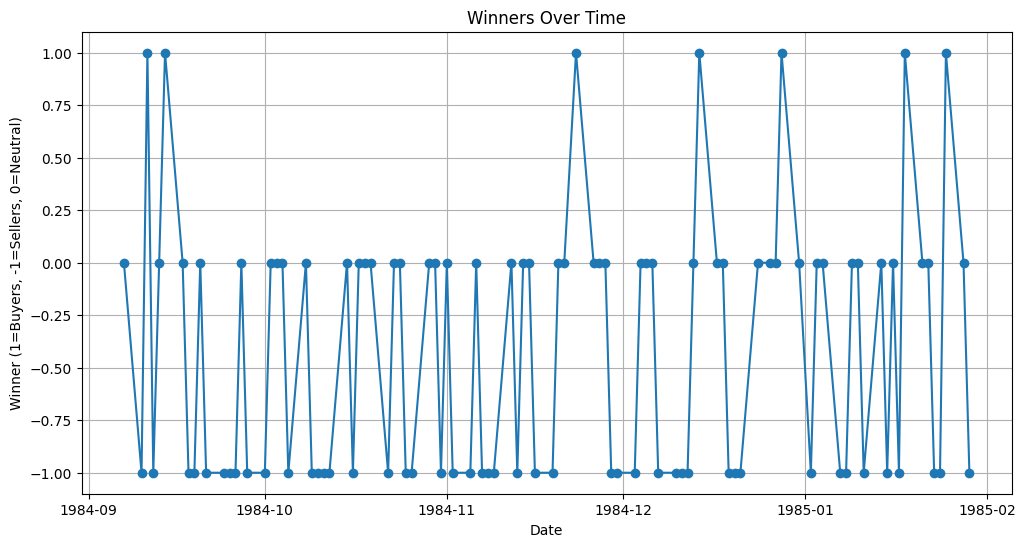

In [9]:
# Map winner categories to numeric values
winner_map = {'buyers': 1, 'sellers': -1, 'neutral': 0}
data['winner_numeric'] = data['winner'].map(winner_map)

# Plot winners over time
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['winner_numeric'], marker='o', linestyle='-')
plt.title('Winners Over Time')
plt.xlabel('Date')
plt.ylabel('Winner (1=Buyers, -1=Sellers, 0=Neutral)')
plt.grid(True)
plt.show()

now well check how much the winners won by

In [10]:
buyer_win = data['Close'] - data['Open']
seller_win = data['Open'] - data['Close']
def winnsers_margin(row):
    if row['winner'] == 'buyers':
        return row['Close'] - row['Open']
    elif row['winner'] == 'sellers':
        return row['Open'] - row['Close']
    else:
        return 0

In [11]:
data['winner_margin'] = data.apply(winnsers_margin, axis=1)

In [12]:
data

,Open,High,Low,Close,Volume,OpenInt,winner,winner_numeric,winner_margin
Date,,,,,,,,,
1984-09-07,0.42388,0.42902,0.41874,0.42388,23220030,0,neutral,0,0.00000
1984-09-10,0.42388,0.42516,0.41366,0.42134,18022532,0,sellers,-1,0.00254
1984-09-11,0.42516,0.43668,0.42516,0.42902,42498199,0,buyers,1,0.00386
1984-09-12,0.42902,0.43157,0.41618,0.41618,37125801,0,sellers,-1,0.01284
1984-09-13,0.43927,0.44052,0.43927,0.43927,57822062,0,neutral,0,0.00000
...,...,...,...,...,...,...,...,...,...
1985-01-23,0.48027,0.48291,0.47251,0.47251,120060735,0,sellers,-1,0.00776
1985-01-24,0.47251,0.47251,0.46357,0.46357,110733964,0,sellers,-1,0.00894
1985-01-25,0.46357,0.47251,0.45335,0.47251,88813324,0,buyers,1,0.00894


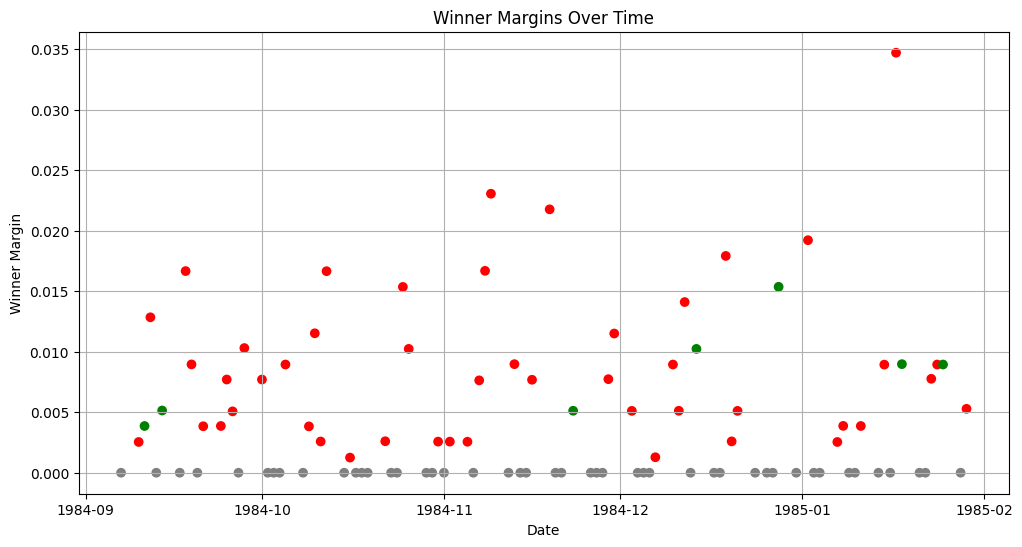

In [13]:
import matplotlib.pyplot as plt

# Assign colors for each winner type
color_map = {'buyers': 'green', 'sellers': 'red', 'neutral': 'gray'}
colors = data['winner'].map(color_map)

plt.figure(figsize=(12, 6))
plt.scatter(data.index, data['winner_margin'], c=colors)
plt.title('Winner Margins Over Time')
plt.xlabel('Date')
plt.ylabel('Winner Margin')
plt.grid(True)
plt.show()